# Breaking Bert

In [3]:
# configuration constants
ALPHA = 0.1

NLIST_GEN_LOWER_BOUND = 70000 # 5000
NLIST_GEN_UPPER_BOUND = 100000 # 55000
NLIST_GEN_NUMBER_STEPS = 3 # 50

K_LOWER_BOUND = 100 # 20
K_UPPER_BOUND = 600 # 1020
K_NUMBER_STEPS = 5 # 50

range_calib = [0.9, 0.7, 0.5, 0.3, 0.1, 0.08, 0.06, 0.04, 0.02]

In [4]:
import math

step_size = (NLIST_GEN_UPPER_BOUND - NLIST_GEN_LOWER_BOUND) / NLIST_GEN_NUMBER_STEPS
range_nlist = [int(math.sqrt(x)) for x in range(NLIST_GEN_LOWER_BOUND, NLIST_GEN_UPPER_BOUND, int(step_size))]
range_nlist_computed = [35, 50, 70, 86, 100, 111, 122, 132, 141, 150, 158, 165, 173, 180, 187, 200, 212, 217, 234, 250, 264, 282, 300]
range_nlist

[264, 282, 300]

In [5]:
range_nlist_to_compute = list(set(range_nlist) - set(range_nlist_computed))
range_nlist_to_compute.sort()
range_nlist_to_compute

[]

In [6]:
step_size = (K_UPPER_BOUND - K_LOWER_BOUND) / K_NUMBER_STEPS
range_k = list(range(K_LOWER_BOUND, K_UPPER_BOUND, int(step_size)))
range_k

[100, 200, 300, 400, 500]

In [ ]:
import subprocess
import os

env = os.environ.copy()
env["OMP_NUM_THREADS"] = "8"

def run_conann(calib, alpha, nlist, k):
    print("running conann on: ", calib, alpha, nlist, k)
    subprocess.run(["./build/eval/error", "bert", str(calib), str(alpha), str(nlist), str(k)], 
                           capture_output=True, 
                           text=False,
                           cwd=os.path.abspath("../conann"),
                           check=True)

def run_faiss(calib, nlist, k, starting_nprobe, alpha):
    print("running faiss on: ", calib, nlist, k, starting_nprobe, alpha)
    result = subprocess.run(["./build/eval/error", "bert", str(calib), str(nlist), str(k), str(starting_nprobe), str(alpha)], 
                           capture_output=True, 
                           text=True,
                           cwd=os.path.abspath("../faiss-1.9.0"),
                           check=True)
    return result.stdout.splitlines()[-1]

    

## Run conann with different parameters

compare nlist and k

In [ ]:
for nlist, k in [(n, k) for n in range_nlist_to_compute for k in range_k]:
    run_conann(0.5, ALPHA, nlist, k)

running conann on:  264 100
running conann on:  264 200
running conann on:  264 300
running conann on:  264 400
running conann on:  264 500
running conann on:  282 100
running conann on:  282 200
running conann on:  282 300
running conann on:  282 400
running conann on:  282 500
running conann on:  300 100
running conann on:  300 200
running conann on:  300 300
running conann on:  300 400
running conann on:  300 500


compare nlist and calib at K100

In [7]:
range_nlist_exp2 = range_nlist_computed[1:-2:2]
range_nlist_exp2

[50, 86, 111, 132, 150, 165, 180, 200, 217, 250]

In [ ]:
for nlist, calib in [(n, c) for n in range_nlist_exp2 for c in range_calib]:
    run_conann(calib, ALPHA, nlist, 100)

running conann on:  0.08 0.1 50 100
running conann on:  0.06 0.1 50 100
running conann on:  0.04 0.1 50 100
running conann on:  0.02 0.1 50 100
running conann on:  0.08 0.1 86 100
running conann on:  0.06 0.1 86 100
running conann on:  0.04 0.1 86 100
running conann on:  0.02 0.1 86 100
running conann on:  0.08 0.1 111 100
running conann on:  0.06 0.1 111 100
running conann on:  0.04 0.1 111 100
running conann on:  0.02 0.1 111 100
running conann on:  0.08 0.1 132 100
running conann on:  0.06 0.1 132 100
running conann on:  0.04 0.1 132 100
running conann on:  0.02 0.1 132 100
running conann on:  0.08 0.1 150 100
running conann on:  0.06 0.1 150 100
running conann on:  0.04 0.1 150 100
running conann on:  0.02 0.1 150 100
running conann on:  0.08 0.1 165 100
running conann on:  0.06 0.1 165 100
running conann on:  0.04 0.1 165 100
running conann on:  0.02 0.1 165 100
running conann on:  0.08 0.1 180 100
running conann on:  0.06 0.1 180 100
running conann on:  0.04 0.1 180 100
running c

baseline values for nlist and k

In [ ]:
for nlist in range_nlist_to_compute:
    starting_nprobe = 10
    for k in range_k:
        next_starting_nprobe = run_faiss(0.5, nlist, k, starting_nprobe, ALPHA)
        print("next starting nprobe: ", next_starting_nprobe)
        starting_nprobe = next_starting_nprobe

running faiss on:  264 100
next starting nprobe:  92
running faiss on:  264 200
next starting nprobe:  97
running faiss on:  264 300
next starting nprobe:  101
running faiss on:  264 400
next starting nprobe:  103
running faiss on:  264 500
next starting nprobe:  105
running faiss on:  282 100
next starting nprobe:  96
running faiss on:  282 200
next starting nprobe:  102
running faiss on:  282 300
next starting nprobe:  105
running faiss on:  282 400
next starting nprobe:  108
running faiss on:  282 500
next starting nprobe:  110
running faiss on:  300 100
next starting nprobe:  100
running faiss on:  300 200
next starting nprobe:  107
running faiss on:  300 300
next starting nprobe:  110
running faiss on:  300 400
next starting nprobe:  113
running faiss on:  300 500
next starting nprobe:  115


## Analyse Results

In [8]:
range_nlist = list(set(range_nlist_computed) | set(range_nlist_to_compute))
range_nlist.sort()
range_nlist

[35,
 50,
 70,
 86,
 100,
 111,
 122,
 132,
 141,
 150,
 158,
 165,
 173,
 180,
 187,
 200,
 212,
 217,
 234,
 250,
 264,
 282,
 300]

In [9]:
avg_vec_in_cluster = [30500/x for x in range_nlist]
avg_vec_in_cluster

[871.4285714285714,
 610.0,
 435.7142857142857,
 354.6511627906977,
 305.0,
 274.77477477477476,
 250.0,
 231.06060606060606,
 216.31205673758865,
 203.33333333333334,
 193.0379746835443,
 184.84848484848484,
 176.30057803468208,
 169.44444444444446,
 163.10160427807486,
 152.5,
 143.8679245283019,
 140.55299539170508,
 130.34188034188034,
 122.0,
 115.53030303030303,
 108.15602836879432,
 101.66666666666667]

In [10]:
import numpy as np

def read_float(filename: str) -> np.array:
    # filename = glob.glob(filename)[0]

    data=[]
    with open(filename, 'r') as f:
        tmpstr = f.readline()
        while (tmpstr):
            data.append(float(tmpstr))
            tmpstr = f.readline()
    return np.array(data)

In [14]:
def import_from_logs(program: str, topic: str, dataset: str, nlist, k, alpha: float = 0.1) -> np.array:
    return read_float(f"../{program}-{topic}-{dataset}_{nlist}_{k}-{alpha}.log")

In [15]:
def import_from_logs_with_calib(program: str, topic: str, dataset: str, nlist, k, calib, alpha: float = 0.1) -> np.array:
    return read_float(f"../{program}-{topic}-{dataset}_{nlist}_{k}-{alpha}-{calib}.log")

# Experiment 1: nlist and k

## Results conann average

In [16]:
results_conann_avg = np.empty(shape=(len(range_nlist), len(range_k)))
# for nlist, k in [(n, k) for n in range_nlist for k in range_k]:
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_k)):
        clusters_searched = import_from_logs("ConANN", "efficiency", "bert", range_nlist[i], range_k[j])
        results_conann_avg[i][j] = np.average(clusters_searched)

In [17]:
display(results_conann_avg)

array([[ 7.18217562,  7.83049367,  8.15203145,  8.41153342,  8.57055483],
       [20.47400612, 21.74748799, 22.42463958, 22.85976409, 23.40148536],
       [20.4617737 , 21.92267366, 22.72870249, 23.29226737, 23.77806903],
       [24.53079948, 26.24814329, 27.16732197, 27.86063783, 28.4945391 ],
       [25.10179118, 26.99519441, 27.96985583, 28.64962866, 29.30624727],
       [27.83660987, 30.08955876, 31.16470074, 31.89296636, 32.61336828],
       [29.109218  , 31.56487549, 32.78855395, 33.59982525, 34.3197903 ],
       [31.08693753, 33.73132372, 34.91786806, 35.72433377, 36.46089996],
       [31.62166885, 34.42682394, 35.68457842, 36.52643076, 37.26081258],
       [33.15989515, 36.06422018, 37.4975972 , 38.41764963, 39.31367409],
       [35.76889471, 38.81651376, 40.31061599, 41.38313674, 42.31542158],
       [36.64001747, 39.88466579, 41.49322848, 42.65443425, 43.67103539],
       [37.88510266, 41.21188292, 42.92267366, 44.14329401, 45.19833989],
       [38.1996505 , 41.69855832, 43.5

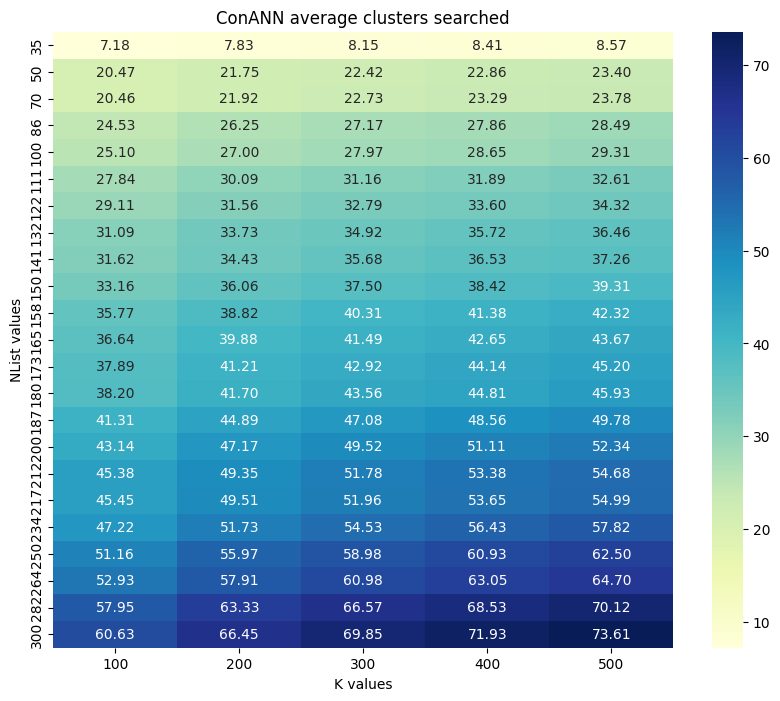

In [18]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_avg, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title('ConANN average clusters searched')
plt.show()

## results conann median

In [19]:
results_conann_median = np.empty(shape=(len(range_nlist), len(range_k)))
# for nlist, k in [(n, k) for n in range_nlist for k in range_k]:
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_k)):
        clusters_searched = import_from_logs("ConANN", "efficiency", "bert", range_nlist[i], range_k[j])
        results_conann_median[i][j] = np.median(clusters_searched)

In [20]:
display(results_conann_median)

array([[ 8.,  9., 10., 11., 11.],
       [24., 26., 27., 27., 28.],
       [25., 27., 27., 27., 28.],
       [30., 32., 32., 33., 33.],
       [30., 33., 33., 34., 34.],
       [33., 36., 37., 37., 38.],
       [33., 37., 38., 38., 39.],
       [35., 40., 41., 41., 42.],
       [36., 41., 41., 42., 43.],
       [36., 41., 43., 44., 44.],
       [39., 45., 46., 47., 48.],
       [40., 46., 47., 48., 50.],
       [41., 46., 48., 49., 50.],
       [41., 46., 48., 49., 50.],
       [44., 50., 52., 53., 54.],
       [46., 52., 54., 55., 56.],
       [48., 54., 56., 57., 58.],
       [48., 53., 56., 57., 58.],
       [50., 55., 58., 60., 61.],
       [54., 60., 63., 65., 66.],
       [55., 61., 65., 66., 68.],
       [62., 68., 71., 73., 74.],
       [64., 71., 74., 76., 77.]])

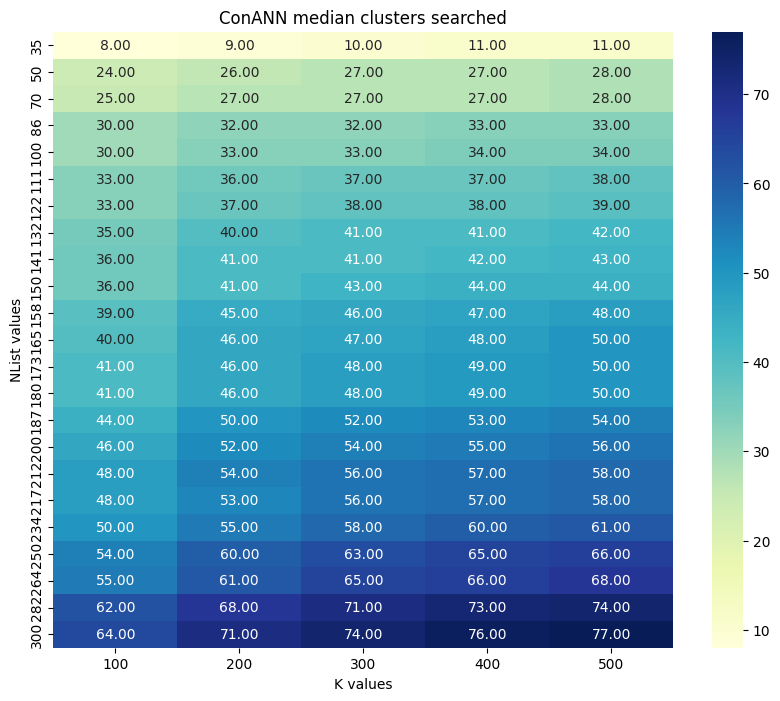

In [21]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_median, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title('ConANN median clusters searched')
plt.show()

In [22]:
results_conann_no_threshold = np.empty(shape=(len(range_nlist), len(range_k)))
# for nlist, k in [(n, k) for n in range_nlist for k in range_k]:
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_k)):
        clusters_searched = import_from_logs("ConANN", "efficiency", "bert", range_nlist[i], range_k[j])
        results_conann_no_threshold[i][j] = np.count_nonzero(clusters_searched == -1)

In [23]:
display(results_conann_no_threshold)

array([[76., 64., 53., 48., 41.],
       [54., 32., 22., 16., 12.],
       [52., 26., 10.,  9.,  9.],
       [49., 37., 23., 18., 15.],
       [41., 28., 25., 26., 18.],
       [56., 29., 27., 23., 18.],
       [57., 29., 26., 24., 16.],
       [55., 46., 27., 24., 22.],
       [52., 49., 28., 24., 21.],
       [52., 30., 27., 23., 19.],
       [39., 24., 20., 19., 17.],
       [39., 28., 23., 20., 19.],
       [44., 32., 24., 19., 18.],
       [49., 38., 28., 23., 18.],
       [43., 33., 30., 26., 22.],
       [41., 32., 28., 27., 20.],
       [43., 37., 34., 33., 25.],
       [43., 36., 36., 33., 25.],
       [51., 47., 43., 40., 31.],
       [47., 37., 32., 29., 16.],
       [41., 40., 36., 31., 18.],
       [56., 46., 38., 31., 18.],
       [45., 37., 28., 12.,  8.]])

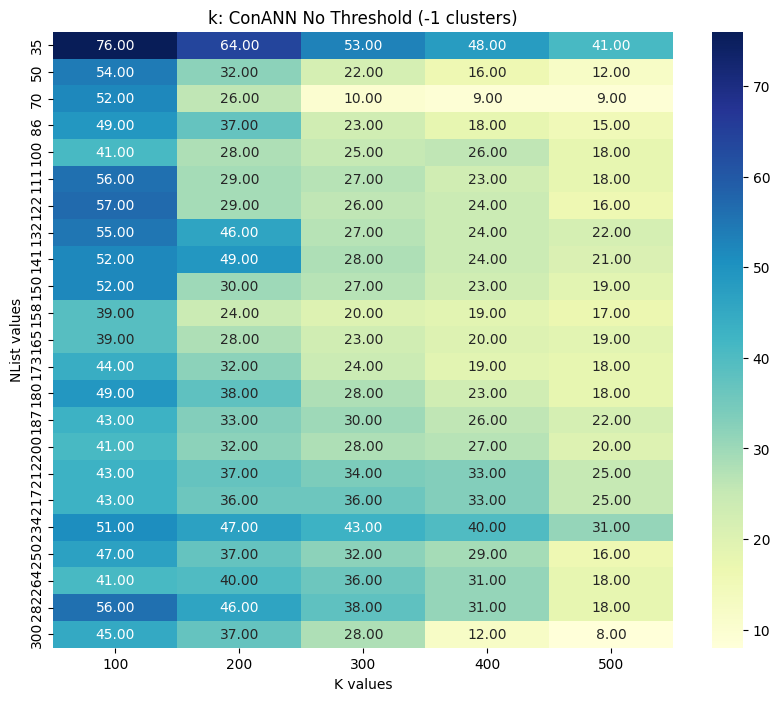

In [24]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_no_threshold, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title('k: ConANN No Threshold (-1 clusters)')
plt.show()

## results faiss

In [25]:
results_faiss = np.empty(shape=(len(range_nlist), len(range_k)))
# for nlist, k in [(n, k) for n in range_nlist for k in range_k]:
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_k)):
        clusters_searched = import_from_logs("Faiss", "efficiency", "bert", range_nlist[i], range_k[j])
        results_faiss[i][j] = clusters_searched[0]

In [26]:
display(results_faiss)

array([[ 14.,  15.,  15.,  15.,  15.],
       [ 25.,  25.,  26.,  26.,  26.],
       [ 33.,  34.,  35.,  35.,  36.],
       [ 41.,  42.,  43.,  44.,  44.],
       [ 48.,  50.,  51.,  52.,  52.],
       [ 53.,  56.,  57.,  58.,  59.],
       [ 56.,  59.,  60.,  61.,  62.],
       [ 57.,  60.,  62.,  63.,  64.],
       [ 59.,  63.,  64.,  65.,  67.],
       [ 61.,  65.,  66.,  68.,  70.],
       [ 66.,  69.,  71.,  72.,  74.],
       [ 66.,  69.,  71.,  72.,  74.],
       [ 69.,  72.,  74.,  76.,  77.],
       [ 72.,  76.,  78.,  80.,  81.],
       [ 68.,  72.,  74.,  76.,  78.],
       [ 71.,  75.,  77.,  79.,  81.],
       [ 73.,  77.,  80.,  82.,  84.],
       [ 73.,  77.,  79.,  82.,  84.],
       [ 78.,  83.,  86.,  88.,  90.],
       [ 85.,  90.,  93.,  96.,  98.],
       [ 92.,  97., 101., 103., 105.],
       [ 96., 102., 105., 108., 110.],
       [100., 107., 110., 113., 115.]])

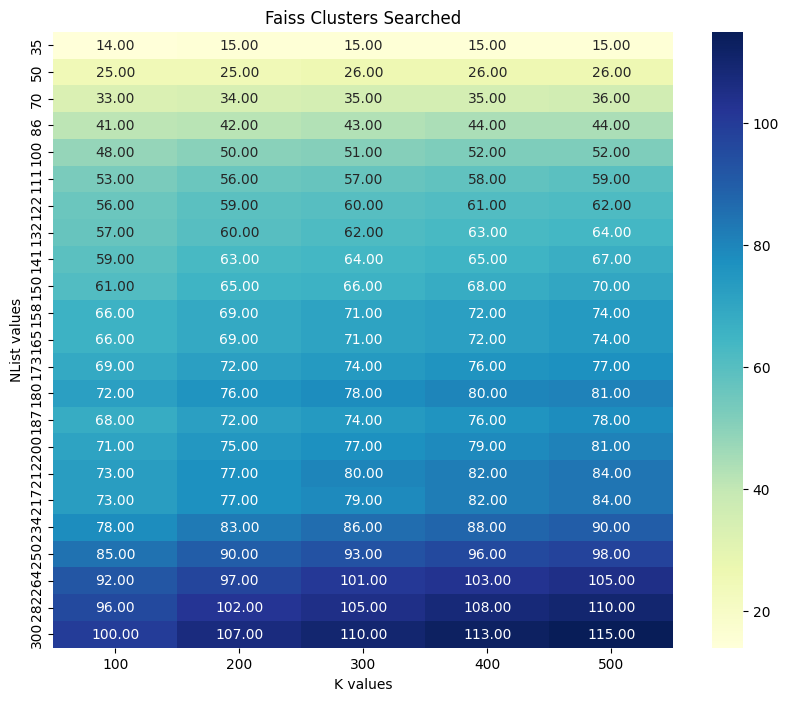

In [27]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_faiss, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title('Faiss Clusters Searched')
plt.show()

## compare

In [28]:
comparison = (results_conann_avg - results_faiss) / results_faiss * 100

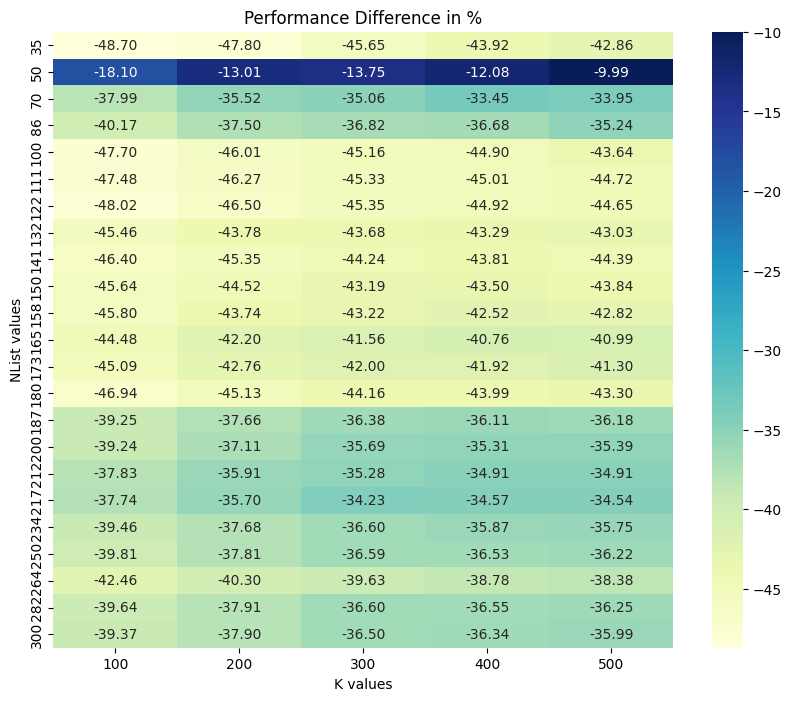

In [29]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(comparison, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title('Performance Difference in %')
plt.show()

# Experiment 2: nlist and calib

In [30]:
results_conann_calib = np.empty(shape=(len(range_nlist_exp2), len(range_calib)))
for i in range(0, len(range_nlist_exp2)):
    for j in range(0, len(range_calib)):
        clusters_searched = import_from_logs_with_calib("ConANN", "efficiency", "bert", range_nlist_exp2[i], 100, range_calib[j])
        results_conann_calib[i][j] = np.average(clusters_searched)

In [31]:
display(results_conann_calib)

array([[19.71179039, 20.20087336, 20.47400612, 20.42527301, 20.30817763,
        20.47079772, 20.35850372, 20.24778157, 20.29306887],
       [24.1441048 , 24.41921397, 24.53079948, 24.35912637, 24.23562242,
        24.22863248, 24.053671  , 24.05756542, 23.78649432],
       [27.74017467, 28.0363901 , 27.83660987, 27.74851794, 27.30963358,
        27.40194682, 27.11315056, 27.13902162, 26.91954535],
       [30.67248908, 31.18631732, 31.08693753, 30.86209048, 30.83329289,
        30.93803419, 30.64358736, 30.77679181, 31.06017384],
       [32.76637555, 33.20887918, 33.15989515, 32.874883  , 32.72628003,
        32.82075024, 32.36710037, 32.87690557, 32.53042122],
       [36.52838428, 36.61644833, 36.64001747, 36.33042122, 36.77335598,
        36.85280152, 36.35246283, 37.07394767, 37.31446401],
       [38.05458515, 38.07714702, 38.1996505 , 37.88549142, 38.02960446,
        38.20465337, 38.0785316 , 38.47258248, 38.47760196],
       [42.73144105, 42.83551674, 43.14285714, 42.55351014, 42

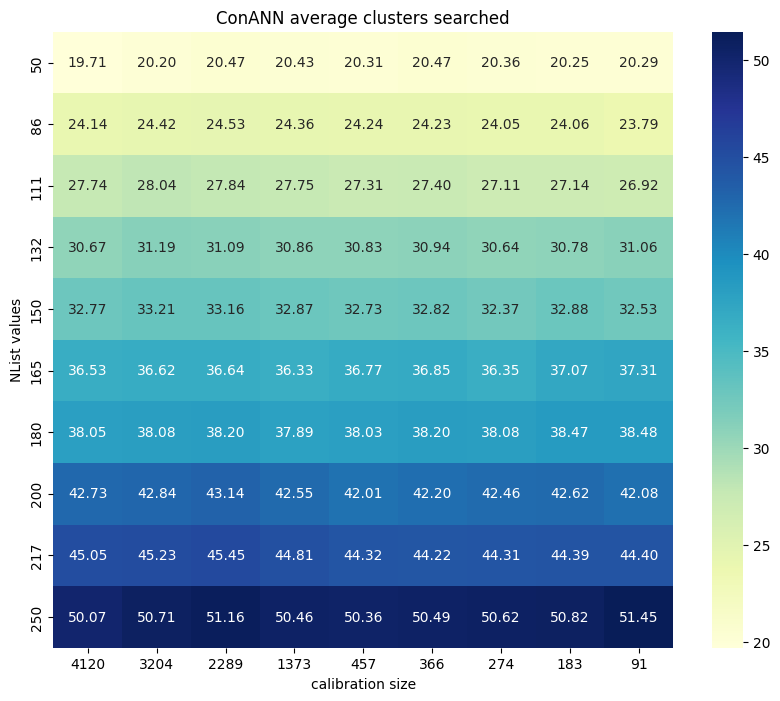

In [32]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_calib, annot=True, fmt=".2f", xticklabels=[int(x * 4578) for x in range_calib], yticklabels=range_nlist_exp2, cmap="YlGnBu")
plt.xlabel('calibration size')
plt.ylabel('NList values')
plt.title('ConANN average clusters searched')
plt.show()

In [33]:
results_conann_calib_no_threshold = np.empty(shape=(len(range_nlist_exp2), len(range_calib)))
for i in range(0, len(range_nlist_exp2)):
    for j in range(0, len(range_calib)):
        clusters_searched = import_from_logs_with_calib("ConANN", "efficiency", "bert", range_nlist_exp2[i], 100, range_calib[j])
        results_conann_calib_no_threshold[i][j] = np.count_nonzero(clusters_searched == -1)

In [34]:
display(results_conann_calib_no_threshold)

array([[ 13.,  34.,  54.,  64.,  80.,  70.,  86.,  96.,  97.],
       [  8.,  26.,  49.,  71.,  98., 101., 116., 120., 134.],
       [ 10.,  30.,  56.,  70., 109., 108., 125., 128., 135.],
       [  9.,  27.,  55.,  74.,  96.,  97., 110., 113., 105.],
       [ 10.,  27.,  52.,  74., 102., 105., 120., 111., 123.],
       [  6.,  20.,  39.,  55.,  60.,  61.,  77.,  62.,  55.],
       [ 10.,  26.,  49.,  70.,  85.,  84.,  93.,  89.,  91.],
       [ 12.,  33.,  41.,  51.,  90.,  86.,  76.,  61., 120.],
       [ 11.,  36.,  43.,  54.,  97., 120., 126., 122., 124.],
       [  8.,  34.,  47.,  57.,  71.,  72.,  74.,  69.,  46.]])

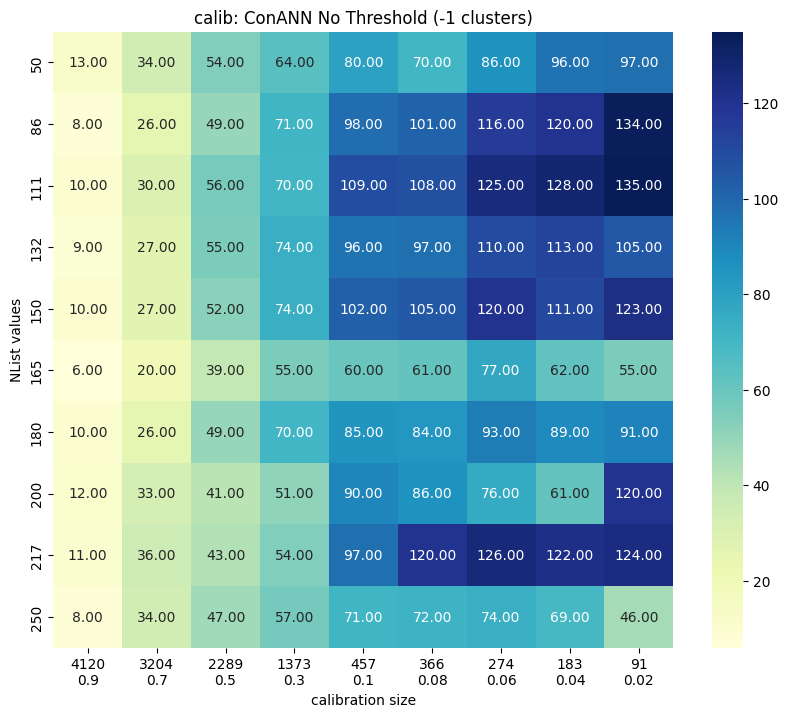

In [35]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_calib_no_threshold, annot=True, fmt=".2f", xticklabels=[f"{int(x * 4578)}\n{x}" for x in range_calib], yticklabels=range_nlist_exp2, cmap="YlGnBu")
plt.xlabel('calibration size')
plt.ylabel('NList values')
plt.title('calib: ConANN No Threshold (-1 clusters)')
plt.show()

In [36]:
validity_conann_calib = np.empty(shape=(len(range_nlist_exp2), len(range_calib)))
for i in range(0, len(range_nlist_exp2)):
    for j in range(0, len(range_calib)):
        fnrs = import_from_logs_with_calib("ConANN", "error", "bert", range_nlist_exp2[i], 100, range_calib[j])
        validity_conann_calib[i][j] = np.average(fnrs)

In [37]:
display(validity_conann_calib)

array([[0.13074236, 0.1155313 , 0.1049585 , 0.09375039, 0.09683329,
        0.08869421, 0.09887314, 0.10818202, 0.10567417],
       [0.08947598, 0.09844978, 0.09611184, 0.09458346, 0.09576316,
        0.09973884, 0.11732342, 0.11845961, 0.13544462],
       [0.09613537, 0.10054585, 0.10679336, 0.09682683, 0.11514924,
        0.11200617, 0.12847351, 0.12786348, 0.13942055],
       [0.0930131 , 0.09221252, 0.09743119, 0.09172231, 0.08482407,
        0.08184236, 0.10341543, 0.09900796, 0.08295966],
       [0.10537118, 0.0986099 , 0.09929227, 0.09658034, 0.09594031,
        0.09479107, 0.12076208, 0.09757679, 0.11439938],
       [0.08340611, 0.0919869 , 0.09631717, 0.09316693, 0.0641883 ,
        0.06329772, 0.09107342, 0.05990444, 0.04921997],
       [0.08600437, 0.09812955, 0.09477501, 0.09357878, 0.07885465,
        0.07477208, 0.08465381, 0.06707622, 0.06780923],
       [0.10061135, 0.09713246, 0.0797204 , 0.08258034, 0.10427566,
        0.09853276, 0.09044377, 0.08173379, 0.11922665],


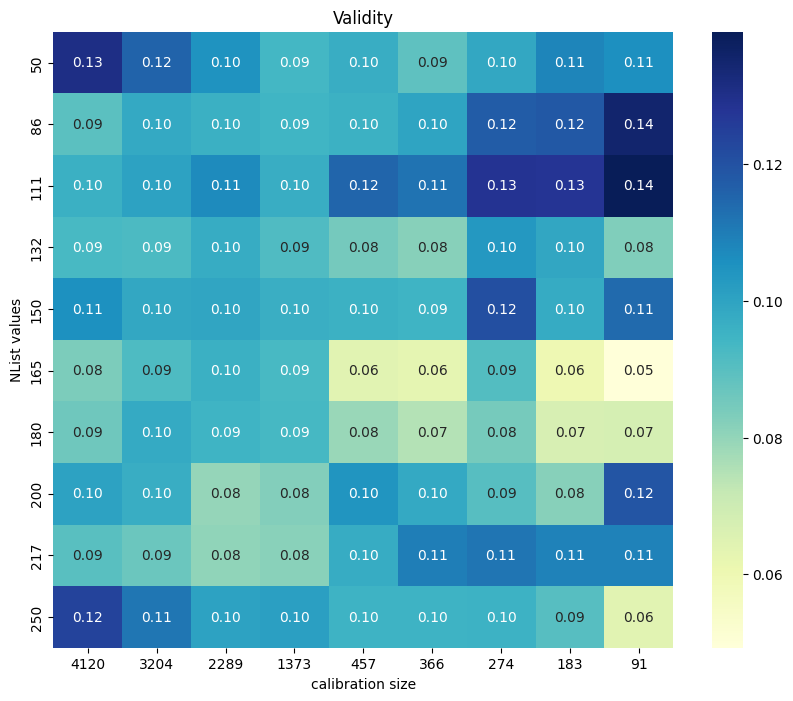

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(validity_conann_calib, annot=True, fmt=".2f", xticklabels=[int(x * 4578) for x in range_calib], yticklabels=range_nlist_exp2, cmap="YlGnBu")
plt.xlabel('calibration size')
plt.ylabel('NList values')
plt.title('Validity')
plt.show()
